# GT Keywords Analysis for DRANK Scale

Collect, stem, and analyze ground truth keywords to determine optimal DRANK scale parameters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
import urllib.request
from bs4 import BeautifulSoup
import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
for package in ['punkt', 'averaged_perceptron_tagger', 'universal_tagset']:
    try:
        nltk.data.find(f'tokenizers/{package}')
    except LookupError:
        nltk.download(package)

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("✓ Libraries imported successfully")

✓ Libraries imported successfully


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/muditha/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /home/muditha/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


In [2]:
def fetch_gt_keywords_from_online(dataset_name='ruoka', num_samples=100):
    """Fetch GT keywords from online UEF dataset"""
    all_keywords = []
    
    base_url = f"https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/{dataset_name}"
    
    for i in range(num_samples):
        try:
            gt_url = f"{base_url}/{i}/GT.txt"
            with urllib.request.urlopen(gt_url, timeout=5) as response:
                gt_text = response.read().decode("utf-8-sig").strip()
                keywords = gt_text.lower().split()
                all_keywords.extend(keywords)
        except Exception as e:
            pass
    
    return list(set(all_keywords))  # Remove duplicates

# Collect keywords from ruoka dataset only
print("Collecting GT keywords from online sources...")
datasets = ["kotiliesi"]
all_gt_keywords = []

for dataset in datasets:
    keywords = fetch_gt_keywords_from_online(dataset, num_samples=100)
    all_gt_keywords.extend(keywords)
    print(f"  {dataset}: {len(keywords)} unique keywords")

# Remove duplicates and create list
all_gt_keywords = list(set(all_gt_keywords))
print(f"\n✓ Total unique GT keywords collected: {len(all_gt_keywords)}")
print(f"Sample keywords: {all_gt_keywords[:10]}")

  kotiliesi: 253 unique keywords

✓ Total unique GT keywords collected: 253
Sample keywords: ['kakku', 'lasityö', 'koristelu', 'titaani', 'leipomine', 'etniset', 'sisustamine', 'kudonta', 'vaatesäilytys', 'koti']


In [3]:
# Initialize Stemmer
try:
    stemmer = SnowballStemmer('finnish')
except:
    stemmer = SnowballStemmer('english')

# Apply stemming to all keywords
stemmed_keywords = [stemmer.stem(keyword) for keyword in all_gt_keywords]

# Create DataFrame with original and stemmed forms
keywords_df = pd.DataFrame({
    'original': all_gt_keywords,
    'stemmed': stemmed_keywords
})

# Remove duplicates in stemmed form (keeping first occurrence)
keywords_df = keywords_df.drop_duplicates(subset=['stemmed'], keep='first').reset_index(drop=True)

print(f"✓ Keywords stemmed")
print(f"  Unique stemmed forms: {len(keywords_df)}")
print(f"\nSample (Original → Stemmed):")
print(keywords_df.head(10).to_string(index=False))


✓ Keywords stemmed
  Unique stemmed forms: 230

Sample (Original → Stemmed):
     original       stemmed
        kakku          kaku
      lasityö       lasityö
    koristelu     koristelu
      titaani          tita
    leipomine        leipom
      etniset         etnis
  sisustamine      sisustam
      kudonta         kudon
vaatesäilytys vaatesäilytys
         koti          koti


In [4]:
# Calculate keyword length statistics
keywords_df['length'] = keywords_df['stemmed'].apply(len)

# Calculate statistics
length_stats = {
    'mean': keywords_df['length'].mean(),
    'median': keywords_df['length'].median(),
    'min': keywords_df['length'].min(),
    'max': keywords_df['length'].max(),
    'std': keywords_df['length'].std()
}

print("✓ Keyword Length Analysis")
print(f"  Mean length: {length_stats['mean']:.2f} characters")
print(f"  Median length: {length_stats['median']:.0f} characters")
print(f"  Min length: {length_stats['min']} characters")
print(f"  Max length: {length_stats['max']} characters")
print(f"  Std Dev: {length_stats['std']:.2f}")

# Length categories
keywords_df['length_category'] = pd.cut(keywords_df['length'], 
                                         bins=[0, 3, 6, 9, 20], 
                                         labels=['Very Short (1-3)', 'Short (4-6)', 'Medium (7-9)', 'Long (10+)'])

length_category_counts = keywords_df['length_category'].value_counts().sort_index()
print(f"\nLength Categories:")
for cat, count in length_category_counts.items():
    print(f"  {cat}: {count} keywords")


✓ Keyword Length Analysis
  Mean length: 7.54 characters
  Median length: 7 characters
  Min length: 3 characters
  Max length: 19 characters
  Std Dev: 3.07

Length Categories:
  Very Short (1-3): 12 keywords
  Short (4-6): 88 keywords
  Medium (7-9): 76 keywords
  Long (10+): 54 keywords


In [5]:
# Function to get POS tag
def get_pos_tag(word):
    """Get POS tag for a word using NLTK"""
    try:
        tokens = word_tokenize(word)
        pos_tags = pos_tag(tokens, tagset='universal')
        return pos_tags[0][1] if pos_tags else 'UNK'
    except:
        return 'UNK'

# Map POS tags to readable labels
pos_mapping = {
    'NOUN': 'Noun',
    'VERB': 'Verb',
    'ADJ': 'Adjective',
    'ADV': 'Adverb',
    'PRON': 'Pronoun',
    'ADP': 'Adposition',
    'CCONJ': 'Conjunction',
    'DET': 'Determiner',
    'NUM': 'Number',
    'X': 'Other',
    'UNK': 'Unknown'
}

# Apply POS tagging
keywords_df['pos_tag_raw'] = keywords_df['stemmed'].apply(get_pos_tag)
keywords_df['pos_tag'] = keywords_df['pos_tag_raw'].apply(lambda x: pos_mapping.get(x, 'Other'))

# Count POS categories
pos_counts = keywords_df['pos_tag'].value_counts()

print("✓ Parts of Speech Analysis")
print(f"\nPOS Distribution:")
for pos, count in pos_counts.items():
    percentage = (count / len(keywords_df)) * 100
    print(f"  {pos}: {count} ({percentage:.1f}%)")


✓ Parts of Speech Analysis

POS Distribution:
  Noun: 225 (97.8%)
  Adjective: 2 (0.9%)
  Verb: 1 (0.4%)
  Pronoun: 1 (0.4%)
  Adverb: 1 (0.4%)


In [6]:
# Create analysis summary for DRANK scale decision
analysis_summary = {
    'Total Keywords': len(keywords_df),
    'Avg Length': f"{length_stats['mean']:.1f}",
    'Most Common Length': f"{keywords_df['length'].mode()[0]}",
    'Length Range': f"{length_stats['min']}-{length_stats['max']}",
    'Most Common POS': pos_counts.index[0],
    'POS Diversity': len(pos_counts)
}

# Create length distribution for DRANK scaling
length_dist = keywords_df['length'].value_counts().sort_index()

# Create POS distribution summary
pos_dist = keywords_df['pos_tag'].value_counts()

print("✓ DRANK Scale Decision Data Prepared")
print("\nSummary Metrics:")
for key, value in analysis_summary.items():
    print(f"  {key}: {value}")

# Save consolidated data
keywords_df_output = keywords_df[['original', 'stemmed', 'length', 'length_category', 'pos_tag']].copy()
print(f"\n✓ Analysis complete. DataFrame has {len(keywords_df_output)} keywords")


✓ DRANK Scale Decision Data Prepared

Summary Metrics:
  Total Keywords: 230
  Avg Length: 7.5
  Most Common Length: 9
  Length Range: 3-19
  Most Common POS: Noun
  POS Diversity: 5

✓ Analysis complete. DataFrame has 230 keywords


✓ Visualization saved as 'gt_keywords_drank_analysis.png'


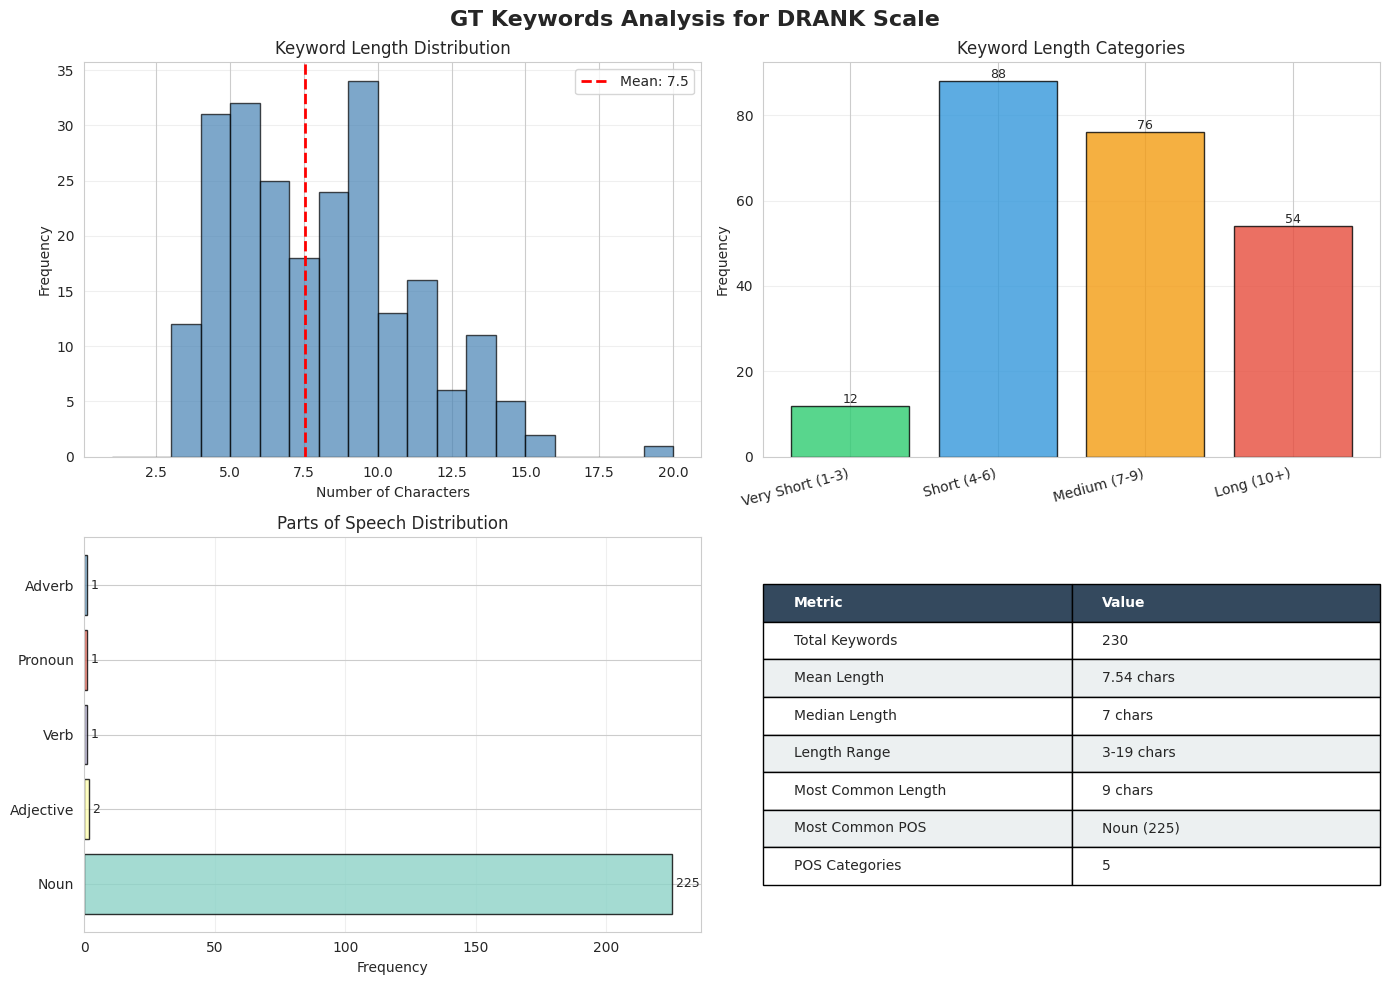

In [7]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GT Keywords Analysis for DRANK Scale', fontsize=16, fontweight='bold')

# 1. Keyword Length Distribution (Histogram)
ax1 = axes[0, 0]
ax1.hist(keywords_df['length'], bins=range(1, int(keywords_df['length'].max()) + 2), 
         color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Number of Characters')
ax1.set_ylabel('Frequency')
ax1.set_title('Keyword Length Distribution')
ax1.grid(axis='y', alpha=0.3)
ax1.axvline(keywords_df['length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {keywords_df["length"].mean():.1f}')
ax1.legend()

# 2. Length Categories (Bar Chart)
ax2 = axes[0, 1]
length_cat_counts = keywords_df['length_category'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax2.bar(range(len(length_cat_counts)), length_cat_counts.values, color=colors, edgecolor='black', alpha=0.8)
ax2.set_xticks(range(len(length_cat_counts)))
ax2.set_xticklabels(length_cat_counts.index, rotation=15, ha='right')
ax2.set_ylabel('Frequency')
ax2.set_title('Keyword Length Categories')
ax2.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

# 3. Parts of Speech Distribution (Bar Chart)
ax3 = axes[1, 0]
pos_counts_top = keywords_df['pos_tag'].value_counts().head(8)
colors_pos = plt.cm.Set3(range(len(pos_counts_top)))
bars = ax3.barh(range(len(pos_counts_top)), pos_counts_top.values, color=colors_pos, edgecolor='black', alpha=0.8)
ax3.set_yticks(range(len(pos_counts_top)))
ax3.set_yticklabels(pos_counts_top.index)
ax3.set_xlabel('Frequency')
ax3.set_title('Parts of Speech Distribution')
ax3.grid(axis='x', alpha=0.3)
# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(width)}', ha='left', va='center', fontsize=9)

# 4. Summary Statistics Table
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')

summary_data = [
    ['Metric', 'Value'],
    ['Total Keywords', f"{len(keywords_df)}"],
    ['Mean Length', f"{length_stats['mean']:.2f} chars"],
    ['Median Length', f"{length_stats['median']:.0f} chars"],
    ['Length Range', f"{length_stats['min']}-{length_stats['max']} chars"],
    ['Most Common Length', f"{keywords_df['length'].mode()[0]} chars"],
    ['Most Common POS', f"{pos_counts.index[0]} ({pos_counts.values[0]})"],
    ['POS Categories', f"{len(pos_counts)}"],
]

table = ax4.table(cellText=summary_data, cellLoc='left', loc='center',
                  colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(2):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data)):
    for j in range(2):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#ffffff')

plt.tight_layout()
plt.savefig('gt_keywords_drank_analysis.png', dpi=150, bbox_inches='tight')
print("✓ Visualization saved as 'gt_keywords_drank_analysis.png'")
plt.show()


In [8]:
# DRANK Scale Recommendations
print("=" * 60)
print("DRANK SCALE CONFIGURATION RECOMMENDATIONS")
print("=" * 60)

# Length-based recommendation
avg_length = keywords_df['length'].mean()
if avg_length < 4:
    length_rec = "SHORT - Scale small, minimal text processing needed"
elif avg_length < 7:
    length_rec = "MEDIUM - Standard scale, moderate processing"
else:
    length_rec = "LONG - Scale large, robust text processing required"

print(f"\n1. LENGTH-BASED SCALE:")
print(f"   Average keyword length: {avg_length:.1f} characters")
print(f"   Recommendation: {length_rec}")

# POS-based recommendation
noun_ratio = (keywords_df['pos_tag'] == 'Noun').sum() / len(keywords_df) * 100
verb_ratio = (keywords_df['pos_tag'] == 'Verb').sum() / len(keywords_df) * 100

print(f"\n2. POS-BASED SCALE:")
print(f"   Noun-dominated: {noun_ratio:.1f}%")
print(f"   Verb-based: {verb_ratio:.1f}%")
if noun_ratio > 50:
    print(f"   Recommendation: NOUN-FOCUSED extraction algorithm")
else:
    print(f"   Recommendation: MIXED POS handling required")

# Complexity recommendation
short_pct = (keywords_df['length'] <= 3).sum() / len(keywords_df) * 100
long_pct = (keywords_df['length'] >= 10).sum() / len(keywords_df) * 100

print(f"\n3. COMPLEXITY SCALE:")
print(f"   Short keywords (≤3 chars): {short_pct:.1f}%")
print(f"   Long keywords (≥10 chars): {long_pct:.1f}%")
if short_pct > 50:
    print(f"   Recommendation: SIMPLE DRANK scale, short keyword handling")
elif long_pct > 30:
    print(f"   Recommendation: COMPLEX DRANK scale, compound word handling")
else:
    print(f"   Recommendation: BALANCED DRANK scale")

# Export results
export_df = keywords_df[['original', 'stemmed', 'length', 'pos_tag']].copy()
export_df.to_csv('gt_keywords_analysis.csv', index=False)
print(f"\n✓ Analysis exported to 'gt_keywords_analysis.csv'")
print("=" * 60)


DRANK SCALE CONFIGURATION RECOMMENDATIONS

1. LENGTH-BASED SCALE:
   Average keyword length: 7.5 characters
   Recommendation: LONG - Scale large, robust text processing required

2. POS-BASED SCALE:
   Noun-dominated: 97.8%
   Verb-based: 0.4%
   Recommendation: NOUN-FOCUSED extraction algorithm

3. COMPLEXITY SCALE:
   Short keywords (≤3 chars): 5.2%
   Long keywords (≥10 chars): 23.5%
   Recommendation: BALANCED DRANK scale

✓ Analysis exported to 'gt_keywords_analysis.csv'


## 8. Map GT Keywords in HTML Tags (Ruoka)

Top tag match rates:
   tag  total_filtered_words  gt_matches  pages    score
    h1                    23           6      6 0.260870
    em                     4           1      1 0.250000
     a                  9312         866    100 0.092998
    h3                    90           4      3 0.044444
  span                  1221          45     39 0.036855
    li                    32           1      1 0.031250
     p                  9962         282     66 0.028308
    td                   418           6      1 0.014354
strong                    91           1      1 0.010989


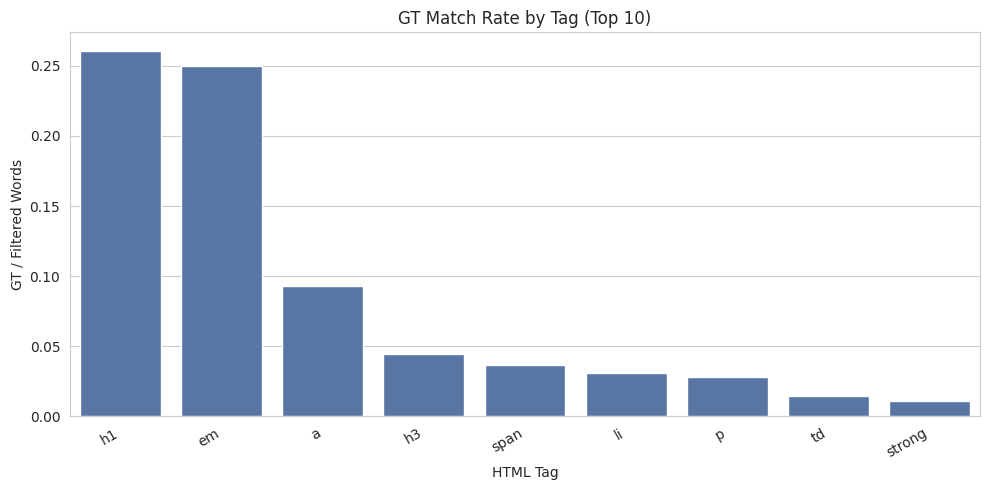


Sample GT locations (first 20):
 page_index  tag gt_stem                                  positions
          0    a    juhl                                       [16]
          0    a   joulu                                       [20]
          0    a   juoma                                       [21]
          0    a  leivon                                       [34]
          0    a    kirj                                       [90]
          0    a   ruoka                                      [104]
          0 span   ruoka                                        [8]
          0    p   joulu                                       [28]
          0    p   ruoka [36, 64, 91, 260, 460, 487, 578, 614, 626]
          0    p   kaava                                      [366]
          0    p    juhl                                      [679]
          1    a    juhl                                       [16]
          1    a   joulu                                       [20]
          1    

In [9]:
import re

def read_url_content(url):
    try:
        with urllib.request.urlopen(url, timeout=8) as response:
            return response.read()
    except Exception:
        return None

def is_visible_text(element):
    if element.parent.name in ["style", "script", "head", "title", "meta", "[document]"]:
        return False
    if element.__class__.__name__ == "Comment":
        return False
    return True

def get_stop_words():
    try:
        return set(stopwords.words('finnish'))
    except Exception:
        try:
            return set(stopwords.words('english'))
        except Exception:
            return set()

stop_words = get_stop_words()

# Extract tokens by HTML tag

def extract_tag_tokens(html_content):
    soup = BeautifulSoup(html_content, "lxml")
    tag_tokens = {}

    for node in soup.find_all(string=True):
        if not is_visible_text(node):
            continue
        text = node.strip()
        if not text:
            continue
        words = re.findall(r"[A-Za-zÅÄÖåäö]+", text.lower())
        if not words:
            continue
        tag = node.parent.name
        tag_tokens.setdefault(tag, []).extend(words)

    return tag_tokens

# Analyze GT keyword locations in tags

def analyze_page_tags(page_index, gt_stems, length_min, length_max):
    base_url = "https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/ruoka"
    html_content = read_url_content(f"{base_url}/{page_index}/")
    if not html_content:
        return None, None

    tag_tokens = extract_tag_tokens(html_content)
    results = []
    locations = []

    for tag, tokens in tag_tokens.items():
        if not tokens:
            continue
        try:
            tagged = pos_tag(tokens, tagset='universal')
        except Exception:
            tagged = [(t, 'UNK') for t in tokens]

        filtered = []
        for idx, (tok, pos_tagged) in enumerate(tagged):
            if tok in stop_words:
                continue
            if len(tok) < length_min or len(tok) > length_max:
                continue
            if pos_tagged != 'NOUN':
                continue
            filtered.append((idx, tok))

        total_filtered = len(filtered)
        if total_filtered == 0:
            continue

        gt_count = 0
        tag_location_map = {}
        for idx, tok in filtered:
            stem = stemmer.stem(tok)
            if stem in gt_stems:
                gt_count += 1
                tag_location_map.setdefault(stem, []).append(idx)

        if gt_count == 0:
            continue

        score = gt_count / total_filtered
        results.append({
            "page_index": page_index,
            "tag": tag,
            "total_filtered_words": total_filtered,
            "gt_matches": gt_count,
            "score": score,
            "unique_gt_matched": len(tag_location_map)
        })

        for stem, positions in tag_location_map.items():
            locations.append({
                "page_index": page_index,
                "tag": tag,
                "gt_stem": stem,
                "positions": positions
            })

    results_df = pd.DataFrame(results).sort_values("score", ascending=False)
    locations_df = pd.DataFrame(locations)
    return results_df, locations_df

# Run analysis for ruoka pages

gt_stems = set(keywords_df['stemmed'].tolist())
length_min = int(length_stats['min'])
length_max = int(length_stats['max'])

pages_to_scan = 100
all_tag_results = []
all_locations = []

for page_index in range(pages_to_scan):
    page_results, page_locations = analyze_page_tags(page_index, gt_stems, length_min, length_max)
    if page_results is not None and not page_results.empty:
        all_tag_results.append(page_results)
    if page_locations is not None and not page_locations.empty:
        all_locations.append(page_locations)

if not all_tag_results:
    print("No GT keyword matches found.")
else:
    tag_results_df = pd.concat(all_tag_results, ignore_index=True)
    location_results_df = pd.concat(all_locations, ignore_index=True) if all_locations else pd.DataFrame(
        columns=["page_index", "tag", "gt_stem", "positions"]
    )

    tag_summary = tag_results_df.groupby("tag", as_index=False).agg(
        total_filtered_words=("total_filtered_words", "sum"),
        gt_matches=("gt_matches", "sum"),
        pages=("page_index", "nunique")
    )
    tag_summary["score"] = tag_summary["gt_matches"] / tag_summary["total_filtered_words"]
    tag_summary = tag_summary.sort_values("score", ascending=False)

    print("Top tag match rates:")
    print(tag_summary.head(10).to_string(index=False))

    plt.figure(figsize=(10, 5))
    plot_df = tag_summary.head(10)
    sns.barplot(data=plot_df, x="tag", y="score", color="#4c72b0")
    plt.title("GT Match Rate by Tag (Top 10)")
    plt.xlabel("HTML Tag")
    plt.ylabel("GT / Filtered Words")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("gt_tag_match_rates.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nSample GT locations (first 20):")
    print(location_results_df.head(20).to_string(index=False))

    tag_summary.to_csv("gt_tag_summary.csv", index=False)
    location_results_df.to_csv("gt_tag_locations.csv", index=False)
    print("\nSaved: gt_tag_summary.csv, gt_tag_locations.csv, gt_tag_match_rates.png")

## DRANK Scale Recommendations

## 7. Visualize Results for DRANK Scale Decision

## 6. Prepare Data for DRANK Scale Decision

## 5. Analyze GT Keyword Parts of Speech

## 4. Analyze GT Keyword Length

## 3. Stem GT Keywords

## 2. Collect GT Keywords from Online Sources

## 1. Import Required Libraries